# Manchester United Performance Analysis & Forecasting (1986 - 2022)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('england.csv')
df['date'] = pd.to_datetime(df['Date'], errors='coerce')

df_post_1986 = df[df['Date'] >= '1986-08-01']

man_utd_home = df_post_1986[df_post_1986['home'] == 'Manchester United']
man_utd_visitor = df_post_1986[df_post_1986['visitor'] == 'Manchester United']
man_utd_matches = pd.concat([man_utd_home, man_utd_visitor]).copy()

def get_goal_for_utd(row):
    if row['home'] == 'Manchester United':
        return row['hgoal']
    else:
        return row['vgoal']

def get_result_for_utd(row):
    if row['home'] == 'Manchester United':
        return row['result']
    else:
        return {'A':'H', 'H':'A', 'D':'D'}.get(row['result'], row['result'])

man_utd_matches['ManUtd_Goals'] = man_utd_matches.apply(get_goal_for_utd, axis=1)
man_utd_matches['ManUtd_Result'] = man_utd_matches.apply(get_result_for_utd, axis=1)

C:\Users\Fly Rice\AppData\Local\Temp\ipykernel_23044\2223673578.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('england.csv')


## Test

In [2]:
print("Number of matches:", len(man_utd_matches))
print(man_utd_matches[['Date', 'home', 'visitor', 'hgoal', 'vgoal', 'ManUtd_Goals', 'ManUtd_Result']].head())

Number of matches: 1390
              Date               home              visitor  hgoal  vgoal  \
131017  1986-08-25  Manchester United      West Ham United      2      3   
131037  1986-08-30  Manchester United    Charlton Athletic      0      1   
131148  1986-09-13  Manchester United          Southampton      5      1   
131300  1986-09-28  Manchester United              Chelsea      0      1   
131379  1986-10-11  Manchester United  Sheffield Wednesday      3      1   

        ManUtd_Goals ManUtd_Result  
131017             2             A  
131037             0             A  
131148             5             H  
131300             0             A  
131379             3             H  


## introduction
### Welcome to my data analysis project exploring the historical performance of Manchester United!

### In this notebook, we dive deep into decades of English football match data to uncover the statistical truths behind one of the world's most famous clubs. Using Python data science libraries like pandas, numpy, and matplotlib, this project moves from foundational data cleaning all the way to predictive modeling.

## Key Highlights of this Analysis:

### Historical Trends: Tracking seasonal goals, points, and overall performance metrics across 36 seasons.

### The "Home Advantage": A statistical comparison of win rates at Old Trafford versus away fixtures to quantify the impact of playing at home.

### Predictive Forecasting: Building a Linear Regression model to analyze the club's long-term mathematical trajectory and predict their win rate for the 2022/2023 season.

## Analysis of Seasonal Performance Trends

In [3]:
result_to_points = {'H': 3, 'D': 1, 'A': 0}
man_utd_matches['points'] = man_utd_matches['ManUtd_Result'].map(result_to_points)

man_utd_matches['Date'] = pd.to_datetime(man_utd_matches['Date'])

def get_season(date):
    year = date.year
    month = date.month

    if month >= 8:
        return f'{year}/{str(year+1)[2:]}'
    else:
        return f'{year-1}/{str(year)[2:]}'

man_utd_matches['Season'] = man_utd_matches['Date'].apply(get_season)

season_stats = man_utd_matches.groupby('Season').agg(
    Total_points=('points','sum'),
    Total_Goals=('ManUtd_Goals','sum'),
    Matches=('ManUtd_Goals','count'),
).reset_index()

season_stats['Avg_Goals_Per_Match'] = season_stats['Total_Goals'] / season_stats['Matches']

Text(0.5, 0.98, 'Manchester United Performance Analysis by Season')

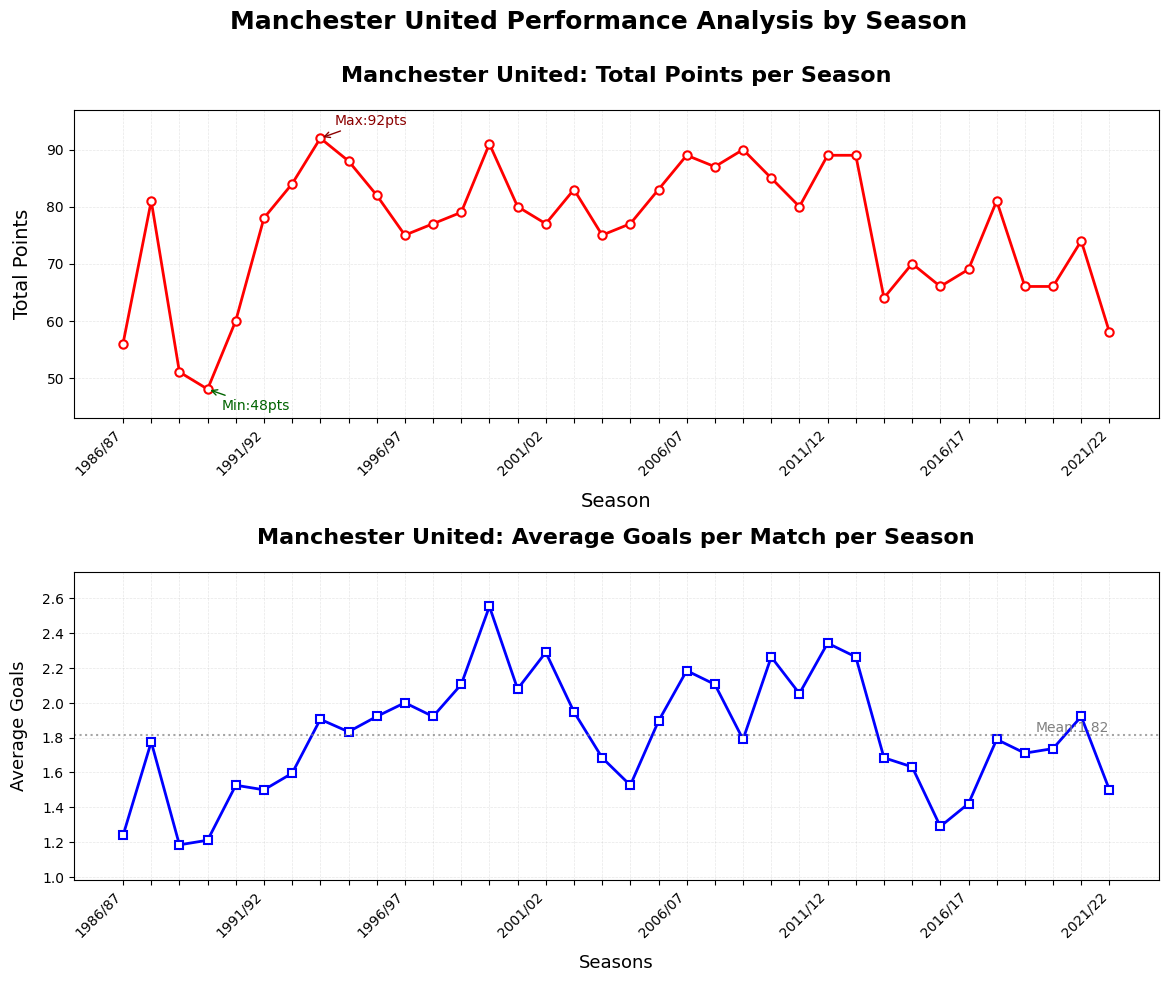

In [4]:
season_stats = season_stats.sort_values('Season')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]#总积分
ax2 = axes[1]#场均进球

line1 = ax1.plot(season_stats['Season'], season_stats['Total_points'], 
                 marker = 'o',
                 linewidth=2,
                 color='red',
                 markersize=6,
                 markerfacecolor='white',
                 markeredgecolor='red',
                 markeredgewidth=1.5)

ax1.set_title('Manchester United: Total Points per Season',
              fontsize=16, fontweight='bold',pad=20)
ax1.set_xlabel('Season', fontsize=14, labelpad=10)
ax1.set_ylabel('Total Points', fontsize=14, labelpad=10)

ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

#设置y轴范围，留出一些空间
y_min = season_stats['Total_points'].min() - 5
y_max = season_stats['Total_points'].max() + 5
ax1.set_ylim(y_min, y_max)

#标记最高点和最低点
max_point = season_stats.loc[season_stats['Total_points'].idxmax()]
min_point = season_stats.loc[season_stats['Total_points'].idxmin()]

ax1.annotate(f'Max:{max_point["Total_points"]}pts',
             xy=(max_point['Season'], max_point['Total_points']), 
             xytext=(10,10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='darkred'),
             fontsize=10, color='darkred')

ax1.annotate(f'Min:{min_point["Total_points"]}pts',
             xy=(min_point['Season'], min_point['Total_points']), 
             xytext=(10,-15), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='darkgreen'),
             fontsize=10, color='darkgreen')

line2 = ax2.plot(season_stats['Season'], season_stats['Avg_Goals_Per_Match'],
                 marker='s',
                 linewidth=2,
                 color='blue',
                 markersize=6,
                 markerfacecolor='white',
                 markeredgecolor='blue',
                 markeredgewidth=1.5)

ax2.set_title('Manchester United: Average Goals per Match per Season',
               fontsize=16,fontweight='bold', pad=20,)

ax2.set_xlabel('Seasons', fontsize=13, labelpad=10)
ax2.set_ylabel('Average Goals', fontsize=13, labelpad=10)

ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

y_min2 = season_stats['Avg_Goals_Per_Match'].min() - 0.2
y_max2 = season_stats['Avg_Goals_Per_Match'].max() + 0.2
ax2.set_ylim(y_min2, y_max2)

#设置水平参考线
avg_goals_mean = season_stats['Avg_Goals_Per_Match'].mean()
ax2.axhline(y=avg_goals_mean, linewidth=1.5, color='gray',linestyle=':', alpha=0.7)
ax2.text(len(season_stats['Season'])-1, avg_goals_mean+0.02,
         f'Mean:{avg_goals_mean:.2f}',
         fontsize=10, color='gray', ha='right')

#由于图表信息比较复杂，需要对x轴做一定的优化处理，避免显示信息的堆叠影响生成图形的信息混乱
for ax in [ax1, ax2]:
    # 获取所有x轴刻度位置和标签
    positions = range(len(season_stats['Season']))
    labels = season_stats['Season'].tolist()

    ax.set_xticks(positions)
    
    show_labels = []
    for i, label in enumerate(labels):
        if i % 5 == 0:  # 每5个显示一个
            show_labels.append(label)
        else:
            show_labels.append('')
    
    ax.set_xticklabels(show_labels, rotation=45, ha='right', fontsize=10)

#调整子图之间的间距
plt.subplots_adjust(hspace=0.5)

# 添加整体标题
fig.suptitle('Manchester United Performance Analysis by Season', 
            fontsize=18, fontweight='bold', y=0.98)



## Manchester United key season performance statistics
### The top 3 seasons with the highest points

In [5]:
print("\n📈 The top 3 seasons with the highest points:")
top_3_points = season_stats.nlargest(3, 'Total_points')
for _, row in top_3_points.iterrows():
    print(f"  {row['Season']}: {row['Total_points']} points")


📈 The top 3 seasons with the highest points:
  1993/94: 92 points
  1999/00: 91 points
  2008/09: 90 points


### The three seasons with the highest average goals per game

In [6]:
top_3_goals = season_stats.nlargest(3, 'Avg_Goals_Per_Match')
for _, row in top_3_goals.iterrows():
    print(f"  {row['Season']}: {row['Avg_Goals_Per_Match']:.2f} goals per match")

  1999/00: 2.55 goals per match
  2011/12: 2.34 goals per match
  2001/02: 2.29 goals per match


### Overall Statistics

In [7]:
print(f"  Average points per season: {season_stats['Total_points'].mean():.1f}")
print(f"  Average goals per game: {season_stats['Avg_Goals_Per_Match'].mean():.2f}")
print(f"  Number of seasons analyzed: {len(season_stats)}")

  Average points per season: 76.1
  Average goals per game: 1.82
  Number of seasons analyzed: 36


In [8]:
man_utd_matches['Venue'] = ['Home' if team == 'Manchester United' else 'Away' for team in man_utd_matches['home']]
man_utd_matches['Win'] = man_utd_matches['ManUtd_Result'] == 'H'
win_rates = man_utd_matches.groupby('Venue')['Win'].mean() * 100

print("Manchester United Win Rates:")
print(win_rates.round(2).astype(str) + '%')

Manchester United Win Rates:
Venue
Away    47.91%
Home    67.63%
Name: Win, dtype: object


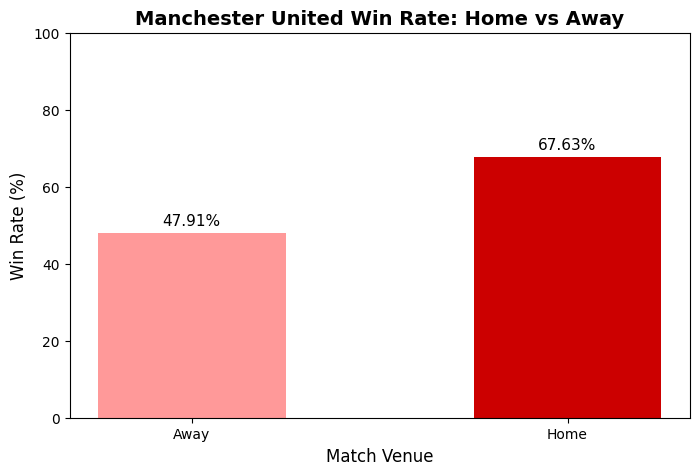

In [9]:
venues = ['Away', 'Home']
rates = [47.91, 67.63]

plt.figure(figsize=(8, 5))

bars = plt.bar(venues, rates, color=['#FF9999', '#CC0000'], width=0.5)

plt.title('Manchester United Win Rate: Home vs Away', fontsize=14, fontweight='bold')
plt.xlabel('Match Venue', fontsize=12)
plt.ylabel('Win Rate (%)', fontsize=12)

plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval}%", ha='center', fontsize=11)

plt.show()

### As the picture shows above, a 67.63% win rate at home versus a 47.91% win rate away clearly shows the famous "Home Advantage" at Old Trafford!

In [10]:
season_win_rates = man_utd_matches.groupby('Season')['Win'].mean() * 100
season_data = season_win_rates.reset_index()

season_data['Year'] = season_data['Season'].astype(str).str[:4].astype(int)

x = season_data['Year']
y = season_data['Win']

slope, intercept = np.polyfit(x, y, 1)

next_season_year = x.max() + 1
predicted_win_rate = (slope * next_season_year) + intercept

print(f"Linear Regression Equation: Win Rate = {slope:.2f} * Year + {intercept:.2f}")
print(f"Predicted Win Rate for year {next_season_year}: {predicted_win_rate:.2f}%")

Linear Regression Equation: Win Rate = 0.22 * Year + -379.99
Predicted Win Rate for year 2022: 61.88%


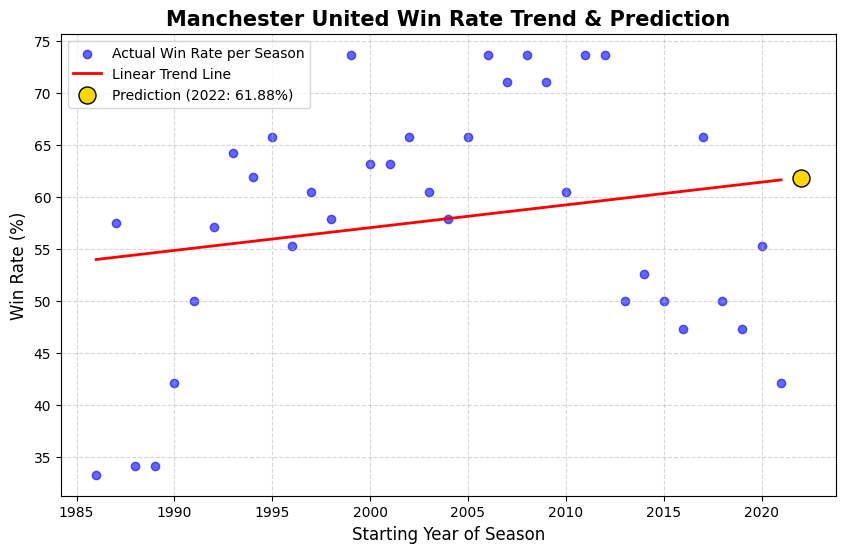

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Actual Win Rate per Season', alpha=0.6)

regression_line = (slope * x) + intercept
plt.plot(x, regression_line, color='red', linewidth=2, label='Linear Trend Line')

plt.scatter(next_season_year, predicted_win_rate, color='gold', s=150, edgecolors='black', label=f'Prediction ({next_season_year}: {predicted_win_rate:.2f}%)', zorder=5)

plt.title('Manchester United Win Rate Trend & Prediction', fontsize=15, fontweight='bold')
plt.xlabel('Starting Year of Season', fontsize=12)
plt.ylabel('Win Rate (%)', fontsize=12)
plt.legend() # This adds the legend box showing what colors mean
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Look at the linear regression image. The slope tells us the general direction Manchester United is heading over the entirety of the historical dataset. Because the slope is a positive number (0.137), it means that, on average, historically, their win rate has had a very slight upward trend. It has predicted that the Mancherster United is expected to have about a 61.88% win rate next season

## Supplement
### What is Linear Regression?
### Imagine you plot Manchester United's win rate for every single season on a scatter plot as a bunch of dots. Linear regression uses math to draw a straight "Line of Best Fit" straight through the middle of those dots. By seeing where that line points at the end, we can make an educated guess (prediction) about the next season!

## Conclusion
### It can be found through inquiries that Manchester United's actual win rate in the 22-23 season was 60.5%. This is close to the predicted result.
### But, it's important to mention that Linear Regression is just a straight line. Real life (especially football!) is not a straight line. It has ups and downs based on new managers, injured players, and transfers. Linear regression simply looks at the long-term mathematical average, but it gives us a great baseline expectation!